[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1jmd0i8UIwprIQVBpGccCGg6aJqz7mLR5?usp=sharing)

# Tutorial: Using TurboQuant (TQ) in <img src="https://qdrant.tech/img/qdrant-logo.svg" width="100" style="vertical-align:middle">

**Author:** [Mohamed Arbi Nsibi](https://www.linkedin.com/in/mohammed-arbi-nsibi-584a43241/)

### Install dependencies

In [3]:
!uv pip install -qU qdrant-client datasets

#### Check library version

In [4]:
import importlib.metadata
print(f"Qdrant client version: {importlib.metadata.version('qdrant-client')}")

Qdrant client version: 1.18.0


### Initialize Qdrant client

In [5]:
from qdrant_client import QdrantClient, models
from datasets import load_dataset
import time

from google.colab import userdata

QDRANT_URL = userdata.get('QDRANT_URL')
QDRANT_API_KEY = userdata.get('QDRANT_API_KEY')

VECTOR_SIZE = 1536
COLLECTION_BASELINE = "dbpedia-baseline-float32"
COLLECTION_TQ = "dbpedia-turboquant-4bit_disk_quant-ram"

client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)

### Create vector collections

In [ ]:


# Baseline Collection (Uncompressed Float32)
if not client.collection_exists(COLLECTION_BASELINE):
    client.create_collection(
        collection_name=COLLECTION_BASELINE,
        vectors_config=models.VectorParams(
            size=VECTOR_SIZE,
            distance=models.Distance.COSINE
        )
    )
    display(f"Created collection: {COLLECTION_BASELINE}")

# TQ collection (4-bit)
if not client.collection_exists(COLLECTION_TQ):
    client.create_collection(
        collection_name=COLLECTION_TQ,
        vectors_config=models.VectorParams(
            size=VECTOR_SIZE,
            distance=models.Distance.COSINE,
            on_disk=True  # keep orig vects on ssd , do not load them into ram
        ),

        quantization_config=models.TurboQuantization(
            turbo=models.TurboQuantQuantizationConfig(
            bits= models.TurboQuantBitSize.BITS4,
            always_ram= True # quant vects into ram
            )
        )
    )
    print(f"Created collection: {COLLECTION_TQ}")

Created collection: dbpedia-turboquant-4bit_disk_quant-ram


### Load and upload dataset

In [ ]:
# Load dataset in streaming mode so don't blow up Colab's RAM
dataset = load_dataset(
    "Qdrant/dbpedia-entities-openai3-text-embedding-3-large-1536-1M",
    split="train",
    streaming=True
)

BATCH_SIZE = 500
MAX_POINTS = 10000

points_to_upload = []

print("Downloading and preparing vectors...")
for idx, row in enumerate(dataset):
    if idx >= MAX_POINTS:
        break

    # Map HuggingFace row to a Qdrant PointStruct
    point = models.PointStruct(
        id=idx,
        vector=row["text-embedding-3-large-1536-embedding"],
        payload={
            "original_id": row["_id"],
            "title": row["title"],
            "text": row["text"][:500] # Truncate text slightly
        }
    )
    points_to_upload.append(point)

    # Upload in batches
    if len(points_to_upload) == BATCH_SIZE:
        print(f"Uploading batch up to {idx + 1}...")
        client.upload_points(collection_name=COLLECTION_BASELINE, points=points_to_upload)
        client.upload_points(collection_name=COLLECTION_TQ, points=points_to_upload)
        points_to_upload.clear()

print("Data upload complete!")
# Give Qdrant moment to finish indexing the quantized vectors
time.sleep(5)

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Uploading batch up to 500...
Uploading batch up to 1000...
Uploading batch up to 1500...
Uploading batch up to 2000...
Uploading batch up to 2500...
Uploading batch up to 3000...
Uploading batch up to 3500...
Uploading batch up to 4000...
Uploading batch up to 4500...
Uploading batch up to 5000...
Uploading batch up to 5500...
Uploading batch up to 6000...
Uploading batch up to 6500...
Uploading batch up to 7000...
Uploading batch up to 7500...
Uploading batch up to 8000...
Uploading batch up to 8500...
Uploading batch up to 9000...
Uploading batch up to 9500...
Uploading batch up to 10000...
Data upload complete!


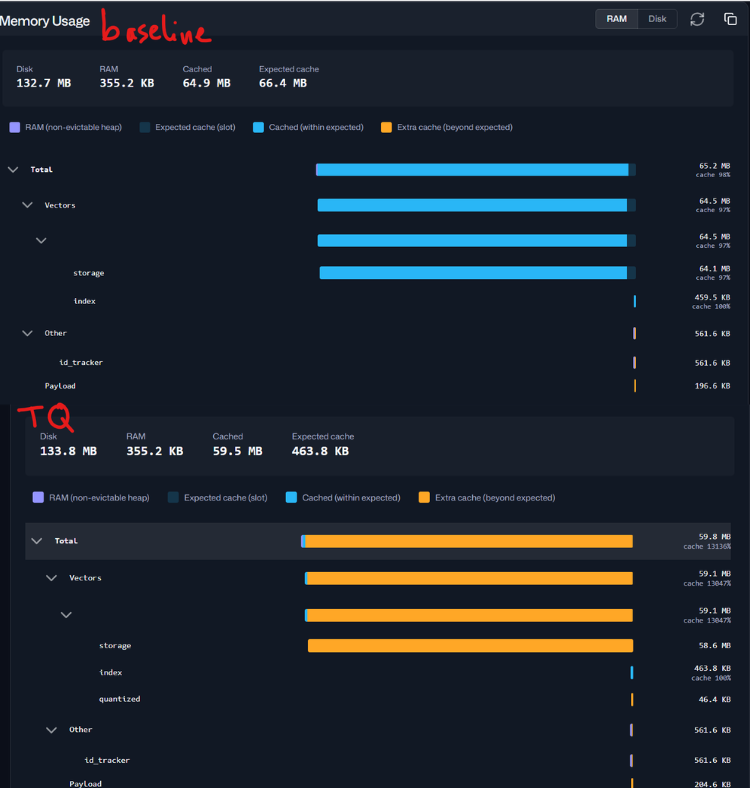

### Compare storage metrics

In [ ]:
info_baseline = client.get_collection(COLLECTION_BASELINE)
info_tq = client.get_collection(COLLECTION_TQ)

# convert bytes to Megabytes
def to_mb(bytes_size):
    return round(bytes_size / (1024 * 1024), 2)

print("\n--- STORAGE COMPARISON ---")
print(f"Baseline (Float32):")
print(f" - Vectors Count: {info_baseline.points_count}")
print(f" - RAM Size: {to_mb(info_baseline.points_count * VECTOR_SIZE * 4)} MB (Approx)") # estimated vector RAM usage

print(f"\nTurboQuant (4-bit):")
print(f" - Vectors Count: {info_tq.points_count}")
print(f" - RAM Size: {to_mb(info_tq.points_count * VECTOR_SIZE * 0.5)} MB (Approx)") # estimated vector RAM usage for 4-bit
basline_ram = to_mb(info_baseline.points_count * VECTOR_SIZE * 4)
tq_ram= to_mb(info_tq.points_count * VECTOR_SIZE * 0.5)
baseline_to_tq = round(basline_ram / tq_ram, 3)
print(f" - Estimated Memory Saved: ~{baseline_to_tq}x less vector memory than baseline.")


--- STORAGE COMPARISON ---
Baseline (Float32):
 - Vectors Count: 10000
 - RAM Size: 58.59 MB (Approx)

TurboQuant (4-bit):
 - Vectors Count: 10000
 - RAM Size: 7.32 MB (Approx)
 - Estimated Memory Saved: ~8.004x less vector memory than baseline.


### Benchmark search recall

In [ ]:
import random

# Sample 100 random IDs from the 10K
num_queries = 100
test_ids = random.sample(range(10000), num_queries)

# Retrieve the actual vectors for these 100 IDs
retrieved_points = client.retrieve(
    collection_name=COLLECTION_BASELINE,
    ids=test_ids,
    with_vectors=True #payloads are returned
)
test_vectors = [point.vector for point in retrieved_points]

print(f"Running empirical benchmark across {num_queries} random queries. Please wait...")

total_recall = 0

for query_vector in test_vectors:
    # Get true Top 10 from Baseline (Ground Truth)
    baseline_results = client.query_points(
        collection_name=COLLECTION_BASELINE,
        query=query_vector,
        limit=10
    )
    true_ids = set(hit.id for hit in baseline_results.points)

    # Top 10 from TQ
    tq_results = client.query_points(
        collection_name=COLLECTION_TQ,
        query=query_vector,
        limit=10
    )
    tq_ids = set(hit.id for hit in tq_results.points)

    # Calculate overlap for this specific query
    overlap = len(true_ids.intersection(tq_ids))
    total_recall += (overlap / 10)

# final average recall
average_recall = (total_recall / num_queries) * 100

print("\n--- RESULTS ---")
print(f"Test Set Size: {num_queries} queries")
print(f"Average Recall@10: {average_recall:.2f}%")
print("(This average proves that TQ maintains extreme accuracy at scale, not just on a lucky single search.)")

Running empirical benchmark across 100 random queries. Please wait...

--- RESULTS ---
Test Set Size: 100 queries
Average Recall@10: 97.30%
(This average proves that TQ maintains extreme accuracy at scale, not just on a lucky single search.)
